In [1]:
import pandas as pd
import numpy as np

import scipy
import scipy.stats as stats
from scipy.stats import shapiro, chi2_contingency, f_oneway

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

## Look for information

In [3]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [5]:
train_data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [6]:
train_data["age"].unique()

array([21, 18, 20, 19, 23, 24, 22, 17])

In [7]:
np.sort(train_data["sleep_hours"].unique())

array([4.1 , 4.15, 4.2 , 4.3 , 4.4 , 4.41, 4.5 , 4.55, 4.56, 4.6 , 4.62,
       4.65, 4.7 , 4.8 , 4.82, 4.9 , 5.  , 5.1 , 5.2 , 5.3 , 5.4 , 5.5 ,
       5.6 , 5.7 , 5.8 , 5.9 , 6.  , 6.1 , 6.2 , 6.3 , 6.4 , 6.5 , 6.6 ,
       6.7 , 6.8 , 6.9 , 7.  , 7.1 , 7.2 , 7.3 , 7.4 , 7.5 , 7.6 , 7.7 ,
       7.8 , 7.9 , 8.  , 8.1 , 8.2 , 8.3 , 8.4 , 8.5 , 8.6 , 8.7 , 8.8 ,
       8.9 , 9.  , 9.1 , 9.2 , 9.3 , 9.4 , 9.5 , 9.6 , 9.7 , 9.8 , 9.9 ])

Useless columns:
- id

Categorical columns: 
- Gender
- Course
- Internet_access
- Sleep quality
- Study_method
- Facility_rating
- Exam_difficulty

Columns with uncertain whether to be in categorical or numerical:
- Age (can be binned into categories or otherwise treated as numerical)

Solution:
- So, I will create two versions of analysis, one treating Age as categorical and other as numerical.

The statistic should not cross across "Course".

In [8]:
train_data["AGE"] = pd.Categorical(train_data["age"])

# Statistical Inference

## Check y's distribution

<Axes: >

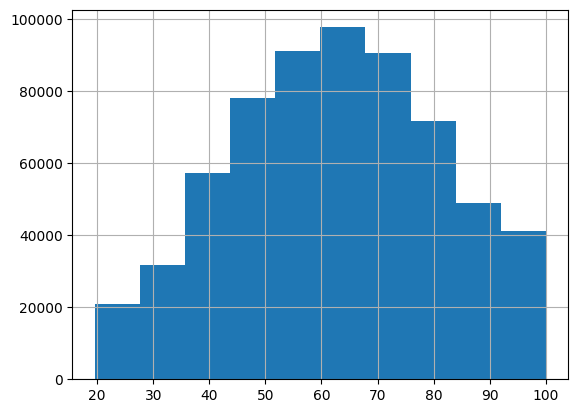

In [9]:
train_data["exam_score"].hist()

In [10]:
shapiro(train_data["exam_score"])

c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 630000.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9895644677659794), pvalue=np.float64(1.9618170647675346e-84))

Here, though the statistic is high, the p-value is very low confirming that the y-value is not normal. 

By the way, the shapiro does not work for count greater than 5000 values as shown in the warning. So, it is better to use different plots like for example, Q-Q plot. 

((array([-4.73408399, -4.5509168 , -4.45178684, ...,  4.45178684,
          4.5509168 ,  4.73408399], shape=(630000,)),
  array([ 19.599,  19.599,  19.599, ..., 100.   , 100.   , 100.   ],
        shape=(630000,))),
 (np.float64(18.818112857561818),
  np.float64(62.506672165079365),
  np.float64(0.9947715099645318)))

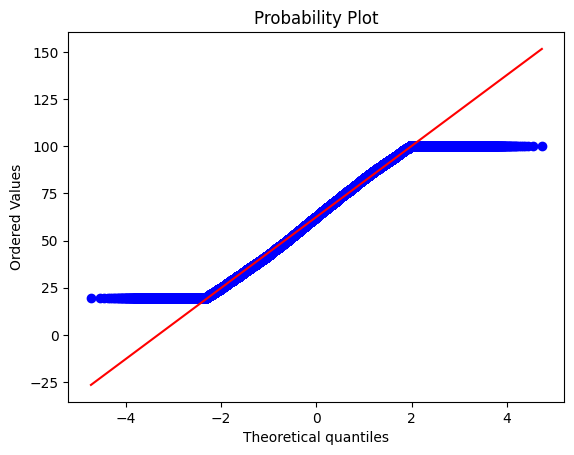

In [11]:
scipy.stats.probplot(train_data["exam_score"], dist="norm", plot=plt)

<Axes: xlabel='exam_score', ylabel='Density'>

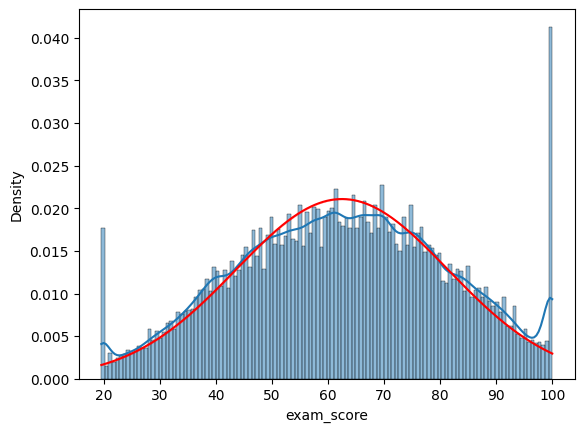

In [12]:
# Line 1: Plot Histogram + KDE
ax = sns.histplot(train_data["exam_score"], kde=True, stat="density")
# Line 2: Plot Normal Distribution
sns.lineplot(
    x=train_data["exam_score"], 
    y=stats.norm.pdf(train_data["exam_score"], *stats.norm.fit(train_data["exam_score"])), 
    color="red", 
    ax=ax
)

Interesting visualization. This shows that the y-value shows the normal distribution but not on the edges. This means that the distribution has heavy tails.

## Check individual contribution w.r.t exam score

### Univariate analysis - Numerical variables

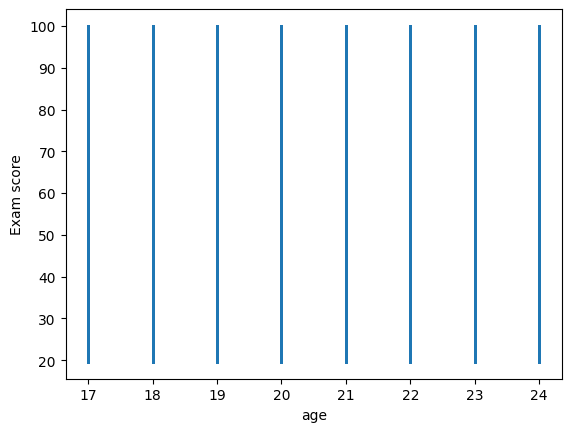

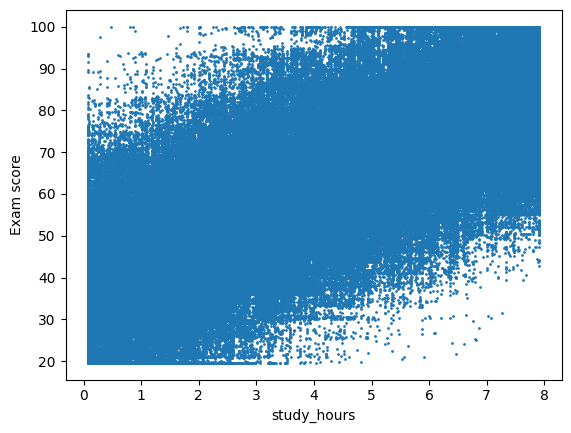

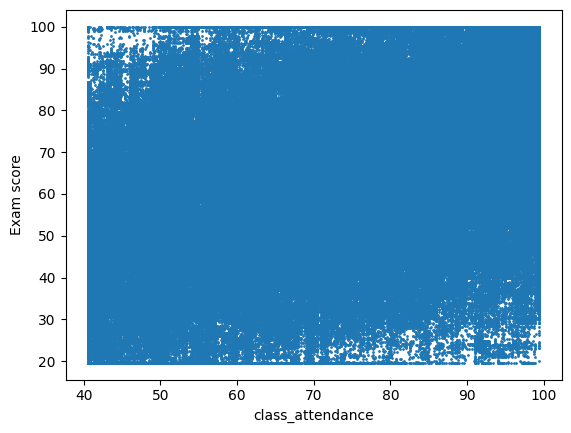

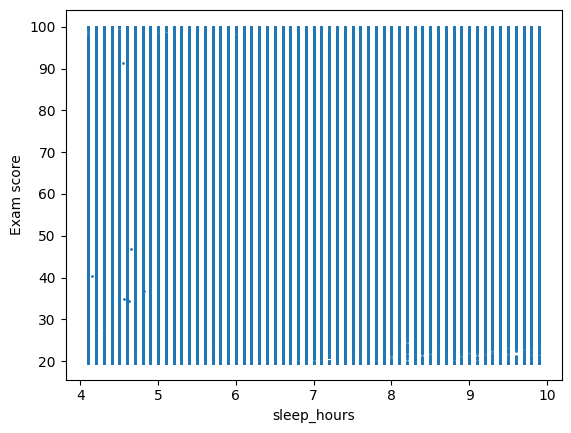

In [13]:
for i in train_data.select_dtypes(include=["int64", "float64"]):
    if i not in ["id", "exam_score"]:
        plt.scatter(train_data[i], train_data["exam_score"], s=1)
        plt.xlabel(f"{i}")
        plt.ylabel(f"Exam score")
        plt.show()

**Visual analysis:** We cannot confirm anything w.r.t the exam score independently for numerical variables except that `study_hours` seems to have better information and `class_attendance` seems to have some information. Rest all numerical variables do not seem to have any information independently.

In [14]:
train_data.select_dtypes(include=["int64", "float64"]).corr()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
id,1.000000,-0.000581,0.000346,0.000677,0.001416,0.000372
age,-0.000581,1.000000,0.007545,0.005628,0.005864,0.010472
study_hours,0.000346,0.007545,1.000000,0.087617,0.042491,0.762267
class_attendance,0.000677,0.005628,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.001416,0.005864,0.042491,0.029263,1.000000,0.167410
exam_score,0.000372,0.010472,0.762267,0.360954,0.167410,1.000000


**Statistical analysis:** The correlation values confirm the visual analysis. Only `study_hours` and `class_attendance` have some correlation with exam score, rest all numerical variables have very low correlation values.
1. We can observe that the exam score increases, when others are constant, from higher to lower order with 
- increase in study hours
- increase in facility rating
- increase in sleep hours (up to a point)

2. Almost all the other numerical variables do not seem to have any information w.r.t others.

3. Age as a numerical variable does not seem to have any information independently w.r.t exam score.

### Multivariate analysis - Numerical variables

In [15]:
sm.OLS(
    endog=train_data["exam_score"], 
    exog=sm.add_constant(train_data.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "exam_score"]))
).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                 3.418e+05
Date:                Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:41:58   Log-Likelihood:            -2.3827e+06
No. Observations:              630000   AIC:                         4.765e+06
Df Residuals:                  629995   BIC:                         4.766e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.9115      0.145     40.898      0.000       5.628       6.195
age                  0.0214      0.006      3.613      0.000       0.010       0.033
study_hours          5.8608      0.006   1028.406      0.000       5.850       5.872
class_attendance     0.3181      0.001    412.530      0.000       0.317       0.320
sleep_hours          1.3850      0.008    180.309      0.000       1.370       1.400
==============================================================================
Omnibus:                      396.490   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              359.937
Skew:                           0.022   Prob(JB):                     6.93e-79
Kurtosis:                       2.892   Cond. No.                         834.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Understanding the result of OLS regression:
- R-squared value is 0.685 which means that 68.5% of the variability in exam score is explained by the numerical variables.
- The constant, study_hours, facility_rating, and sleep_hours have p-values less than 0.05 (see column `P>|t|`) indicating that they are statistically significant predictors of exam score.
- The coefficients indicate the expected change in exam score for a one unit increase in the predictor variable, holding all other variables constant. For example, for each additional hour of study, the exam score is expected to increase by approximately 5.8609 points.
- The constant term (intercept, representated by `const`) is 6.3486, which is the expected exam score when all predictor variables are zero.
- The t-statistic (column `t`) indicates how many standard deviations the coefficient is away from zero. Higher absolute values indicate more significant predictors. $t = \frac{coef}{std\ error}$
- We can observe that the standard errors are relatively small compared to the coefficients, indicating that the estimates are precise.
- Skewness is 0.022 and kurtosis is 2.91 which indicates that the residuals are approximately normally distributed. The real normal distribution has skewness 0 and kurtosis 3.
- There is no use of age as a numerical variable as its coefficient is very small, though the p-value is less than 0.05.

DO NOT CONFUSE PEARSON CORRELATION WITH COEFFICIENTS IN MULTIVARIATE REGRESSION.
1. Pearson correlation measures the linear relationship between two variables without considering the influence of other variables. It ranges from -1 to 1, where values close to 1 or -1 indicate a strong linear relationship, and values close to 0 indicate little to no linear relationship.
2. In contrast, coefficients in multivariate regression represent the expected change in the dependent variable for a one-unit change in a predictor variable, while holding all other predictor variables constant. This means that the coefficient reflects the unique contribution of that predictor to the outcome, accounting for the presence of other predictors in the model.
3. Now, if we consider max sleep gain from 4 to 9 hours, the coefficient is 1.38, implying that $9 - 4 = 5$ hours increase in sleep leads to $5 * 1.38 = 6.9$ points increase in exam score, when all other variables are held constant. But, if we consider max attendance gain from 40% to 100%, the coefficient is 0.31, implying that $100 - 40 = 60$ % increase in attendance leads to $60 * 0.31 = 18.6$ points increase in exam score, when all other variables are held constant. This shows that attendance has more impact on exam score than sleep hours, showing the effect of Pearson correlation where attendance (0.36) is higher than sleep hours (0.167).

### Univariate analysis - Categorical variables

C:\Users\Peeyush\AppData\Local\Temp\ipykernel_30604\375733813.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.plot.box(column="exam_score", by=i, ax=ax[index, 0])


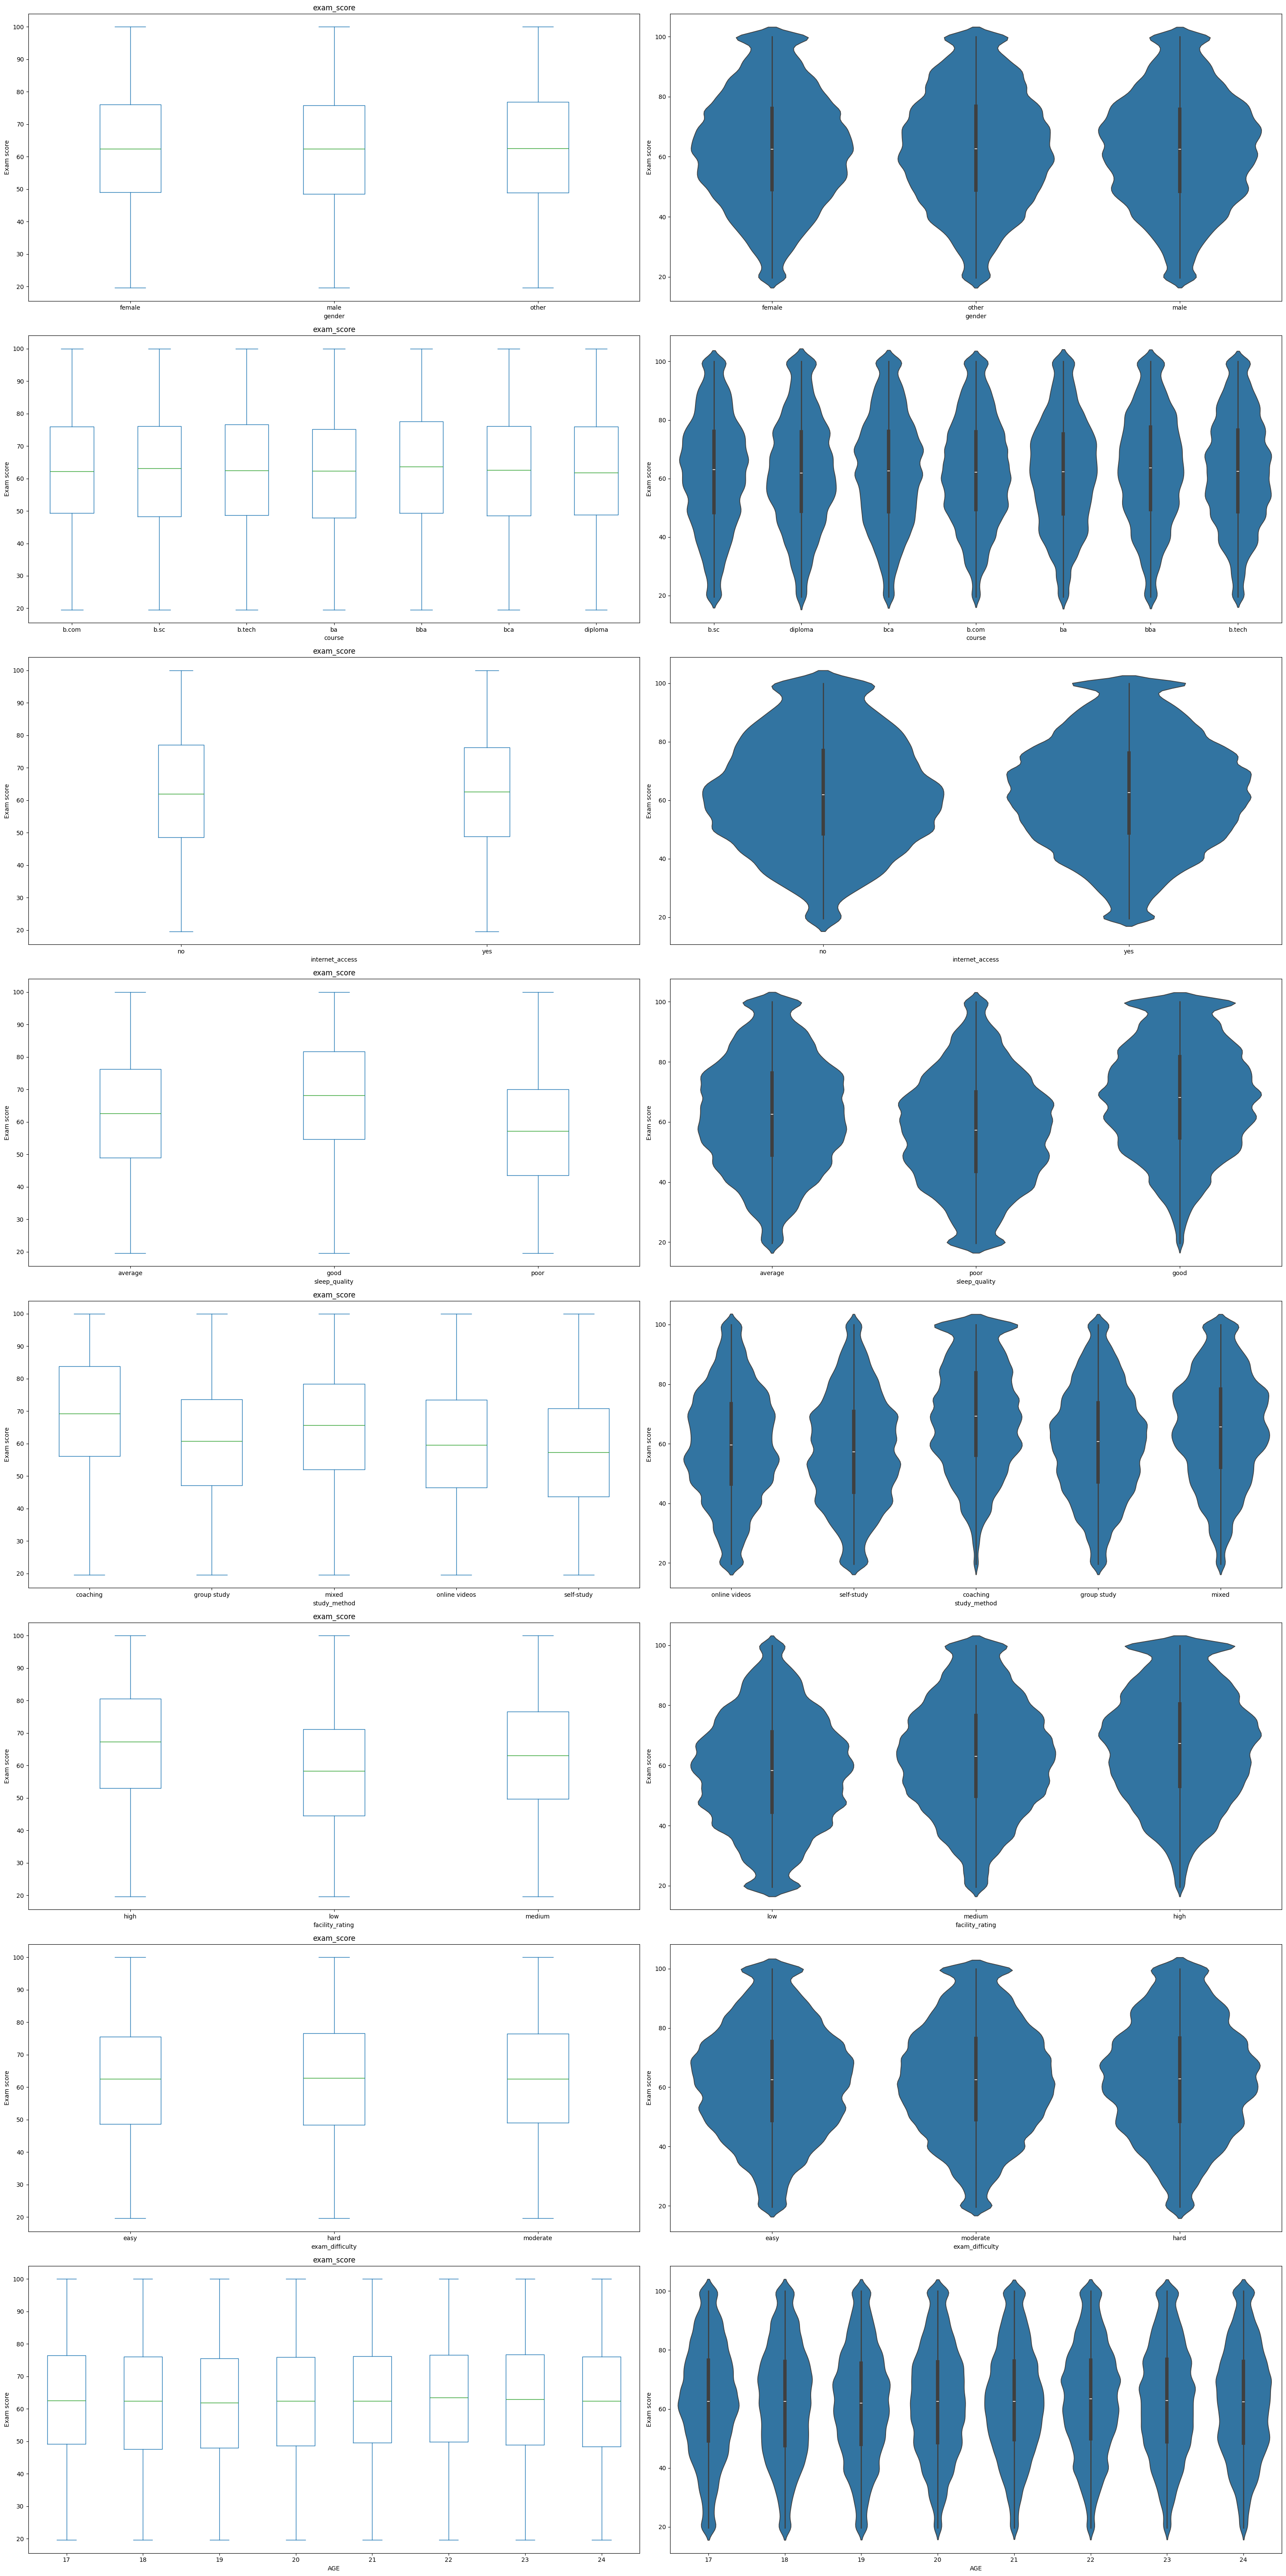

In [16]:
categorical_columns = train_data.select_dtypes(include=["category", "object"])
fig, ax = plt.subplots(categorical_columns.shape[1], 2, figsize=(30, 60))

for index, i in enumerate(categorical_columns):
    train_data.plot.box(column="exam_score", by=i, ax=ax[index, 0])
    sns.violinplot(x=i, y="exam_score", data=train_data, ax=ax[index, 1])
    ax[index, 0].set_xlabel(i)
    ax[index, 0].set_ylabel("Exam score")
    ax[index, 1].set_xlabel(i)
    ax[index, 1].set_ylabel("Exam score")
plt.tight_layout()
plt.show()

**Visual Analysis:** We can observe that `exam_difficulty`, `facility_rating`, `sleep_quality` and `study_method` seem to have some information w.r.t exam score. Rest all categorical variables do not seem to have any information independently. 

In [17]:
anova_results = []
for i in categorical_columns:
    f_oneway_result = f_oneway(
        *[group["exam_score"].values for name, group in train_data.groupby(i)]
    )
    anova_results.append({"Variable": i, "F-statistic": f_oneway_result.statistic, "p-value": f_oneway_result.pvalue, "significant": f_oneway_result.pvalue < 0.05})
anova_df = pd.DataFrame(anova_results)
anova_df.sort_values(by="F-statistic", ascending=False)

C:\Users\Peeyush\AppData\Local\Temp\ipykernel_30604\1055193808.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  *[group["exam_score"].values for name, group in train_data.groupby(i)]


,Variable,F-statistic,p-value,significant
3,sleep_quality,18739.185565,0.000000e+00,True
5,facility_rating,11664.965996,0.000000e+00,True
4,study_method,8304.288536,0.000000e+00,True
0,gender,55.427932,8.512806e-25,True
7,AGE,45.765388,2.812330e-65,True
1,course,32.517776,2.117286e-39,True
6,exam_difficulty,29.744487,1.209882e-13,True
2,internet_access,0.126003,7.226126e-01,False


**Statistical Analysis:** We can observe that:
- `sleep_quality`, `facility_rating` and `study_method` have a clear F-statistic indicating their significance.
- Rest others have very low F-statistic indicating their micromovement or insignificance.
- `internet_access` has very high p-value indicating its insignificance.

### Multivariate analysis - Categorical variables

In [18]:
from sklearn.preprocessing import OneHotEncoder

# Why should we drop first?
# To avoid the dummy variable trap (multicollinearity) in regression models.
# If we include all categories, one category can be perfectly predicted from the others - This is a multicollinearity issue.
enc = OneHotEncoder(drop="first", sparse_output=False)
cat_train_data = enc.fit_transform(train_data[["sleep_quality", "facility_rating", "study_method"]])
cat_train_data = pd.DataFrame(cat_train_data, columns=enc.get_feature_names_out())
cat_train_data

,sleep_quality_good,sleep_quality_poor,facility_rating_low,facility_rating_medium,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
629995,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
629996,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
629997,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
629998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
numeric_cat_data = pd.concat([train_data[["study_hours", "class_attendance", "sleep_hours"]], cat_train_data], axis=1)
numeric_cat_data

,study_hours,class_attendance,sleep_hours,sleep_quality_good,sleep_quality_poor,facility_rating_low,facility_rating_medium,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,7.91,98.8,4.9,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,4.95,94.8,4.7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,4.68,92.6,5.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,7.65,86.9,9.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
629995,4.86,70.7,4.1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
629996,7.08,54.4,4.5,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
629997,0.64,44.2,4.3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
629998,1.54,75.1,8.2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<Axes: >

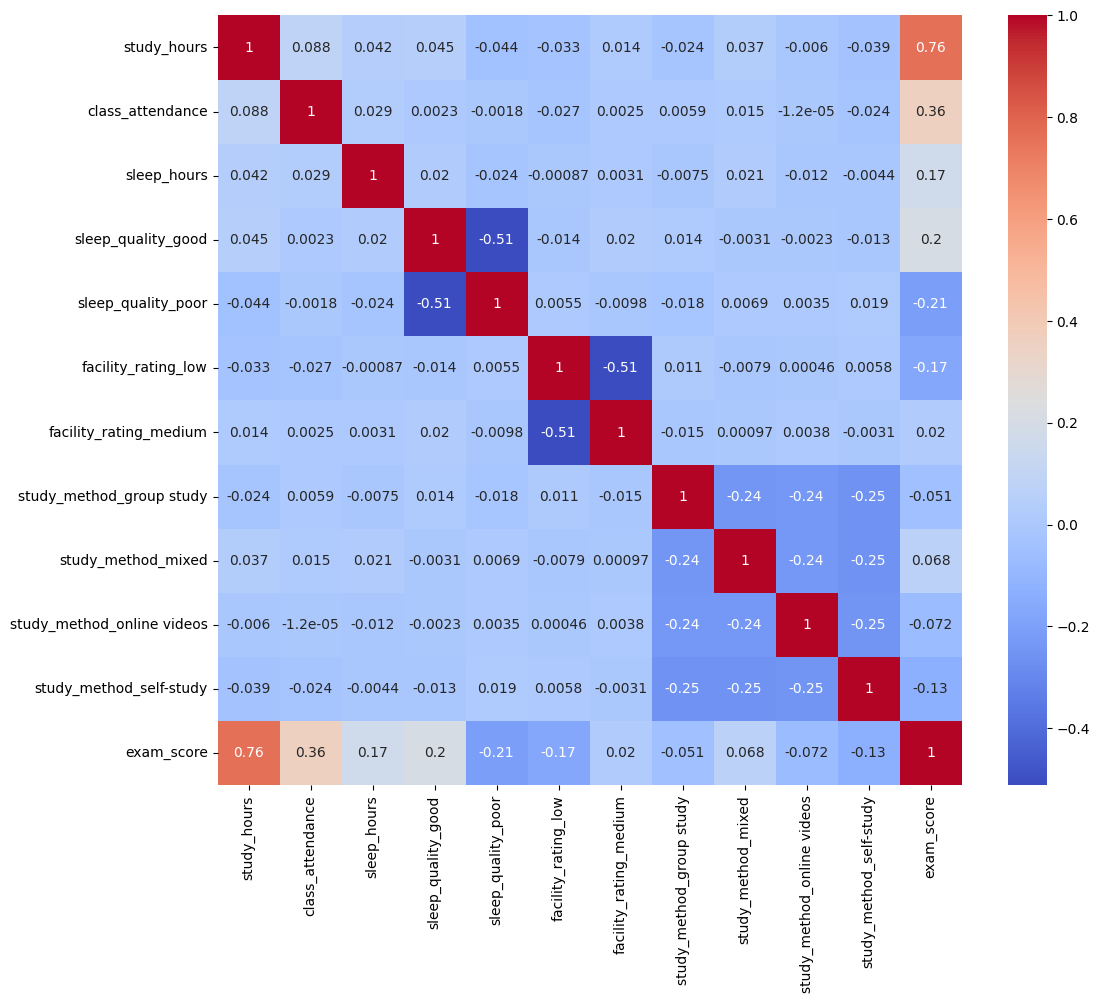

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(numeric_cat_data.join(train_data["exam_score"]).corr(), annot=True, cmap="coolwarm", ax=ax)

In [21]:
sm.OLS(
    endog=train_data["exam_score"],
    exog=sm.add_constant(numeric_cat_data)
).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                 2.017e+05
Date:                Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:42:47   Log-Likelihood:            -2.2709e+06
No. Observations:              630000   AIC:                         4.542e+06
Df Residuals:                  629988   BIC:                         4.542e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         17.5534      0.074    237.125      0.000      17.408      17.698
study_hours                    5.6767      0.005   1185.542      0.000       5.667       5.686
class_attendance               0.3123      0.001    483.342      0.000       0.311       0.314
sleep_hours                    1.3219      0.006    205.422      0.000       1.309       1.335
sleep_quality_good             4.2371      0.028    153.525      0.000       4.183       4.291
sleep_quality_poor            -4.6802      0.028   -169.680      0.000      -4.734      -4.626
facility_rating_low           -7.2779      0.028   -263.498      0.000      -7.332      -7.224
facility_rating_medium        -3.5912      0.028   -130.352      0.000      -3.645      -3.537
study_method_group study      -7.2346      0.035   -204.909      0.000      -7.304      -7.165
study_method_mixed            -4.4527      0.035   -126.219      0.000      -4.522      -4.384
study_method_online videos    -8.2867      0.035   -233.859      0.000      -8.356      -8.217
study_method_self-study       -9.1086      0.035   -262.098      0.000      -9.177      -9.041
==============================================================================
Omnibus:                       22.033   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.033
Skew:                          -0.014   Prob(JB):                     1.64e-05
Kurtosis:                       3.007   Cond. No.                         520.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Statistical Analysis:** We found that 
- Good sleep quality leads to better exam score.
- Better facility (Here, it is zero since it is not there but can be compared with lower facility rating) rating leads to better exam score.
- Coaching leads to better exam score. 
- OLS regression shows with $R^2 = 0.779$, which is a strong baseline.

## Random forest regression

We tried to fit a plane using OLS. Now, can we divide this problem into multiple if/else statements? Yes, we can use decision trees for that. But decision trees have high variance. So, we can use random forest regression which is an ensemble of decision trees to reduce the variance.

We will use the same training features as used in OLS to compare whether Random forest regressor is good or not.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(numeric_cat_data, train_data["exam_score"])

y_pred = rf.predict(numeric_cat_data)
print(f"Random forest R^2 score:", r2_score(train_data["exam_score"], y_pred))

Random forest R^2 score: 0.9657727902808764


It seems to overfit the data but it is always better to check by dividing.

Why did I train the Random Forest with full training data and then start dividing to check?

Reason: We wanted to compare OLS with Random Forest on equal grounds - I mean equal amount of data and other variables. First thing we need to know is whether Random Forest is better than OLS or not. If it is not better, there is no point in tuning hyperparameters of Random Forest. So, we trained it on full data first to see how well it performs. Now, we will divide the data to see whether it is overfitting or not. If it is not overfitting, we can say that Random Forest is better than OLS. If it is overfitting, we can do hyperparameter tuning to reduce overfitting and then compare with OLS.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(numeric_cat_data, train_data["exam_score"], train_size=0.8, random_state=42)
fit_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
fit_rf.fit(X_train, y_train)
y_pred = fit_rf.predict(X_val)
print(f"Random forest Train R^2 score:", r2_score(y_train, fit_rf.predict(X_train)))
print(f"Random forest Test R^2 score:", r2_score(y_val, y_pred))

Random forest Train R^2 score: 0.9658793651557234
Random forest Test R^2 score: 0.7545633983932605


In [27]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((504000, 11), (126000, 11), (504000,), (126000,))

Yes, now we can see that Random Forest is overfitting the data as the train R^2 score is very high (0.99) and test R^2 score is low (0.75). We can do hyperparameter tuning to reduce overfitting and then compare with OLS.

``A model can be trained when it can overfit.``

Now, creation of random forest with an educated guess. 

Each final cell in the random forest should contain at least 50 samples because of Central Limit Theorem.

Maximum depth size can be 10 because log2(1024) = 10  where 1024 becomes the maximum leaves possible with depth 10.

Since we know that the length of training data is 5 lakh, each cell on an average can contain 500000/1024 = 488 samples which is greater than 50. So, we can create a random forest with max depth 10.

In doubt, you can take max_depth = 13 since 2^13 = 8192 and 500000/8192 = 61 samples per cell on an average which is still greater than 50.

In [34]:
new_rf = RandomForestRegressor(
    n_estimators=100,
    min_samples_leaf=50,
    max_depth=13,
    random_state=42,
    n_jobs=-1
)
new_rf.fit(X_train, y_train)
y_pred = new_rf.predict(X_val)
print(f"New Random forest Train R^2 score:", r2_score(y_train, new_rf.predict(X_train)))
print(f"New Random forest Test R^2 score:", r2_score(y_val, y_pred))

New Random forest Train R^2 score: 0.7833915493065311
New Random forest Test R^2 score: 0.7699990965440461


Seems like the random forest model is not much of a greater model than OLS since its test R^2 score is 0.75 which is less than OLS's 0.779. Lets check with XGBoost to tell whether Random Forest is better or not.

In [35]:
import xgboost as xgb
from sklearn.metrics import r2_score

# 1. Initialize XGBoost
# We use 'reg:squarederror' for regression
xg_reg = xgb.XGBRegressor(
    objective ='reg:squarederror', 
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=13, 
    n_jobs=-1, 
    random_state=42
)

# 2. Fit on the same Training Data
xg_reg.fit(X_train, y_train)

# 3. Predict
train_pred_xgb = xg_reg.predict(X_train)
test_pred_xgb = xg_reg.predict(X_val)

print(f"XGBoost Train R2: {r2_score(y_train, train_pred_xgb):.4f}")
print(f"XGBoost Test R2:  {r2_score(y_val, test_pred_xgb):.4f}")
print(f"Baseline OLS R2:  0.7790")

XGBoost Train R2: 0.8641
XGBoost Test R2:  0.7745
Baseline OLS R2:  0.7790


From rigorous data science, we can say that Random Forest is not that much better than OLS.

## Polynomial Features with OLS

In [36]:
from sklearn.preprocessing import PolynomialFeatures

# We only give polynomial features to numeric data 
# becaue categorical data when multiplied do not make sense 
# (1 * 0 = 0, but what does that mean for categories?)
cols_to_use = ["study_hours", "class_attendance", "sleep_hours"]
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(train_data[cols_to_use])
poly_feature_names = poly.get_feature_names_out(cols_to_use)
X_poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)

X_final_poly = pd.concat([X_poly_df, cat_train_data], axis=1)
sm.OLS(
    endog=train_data["exam_score"],
    exog=sm.add_constant(X_final_poly)
).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                 1.306e+05
Date:                Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:47:38   Log-Likelihood:            -2.2707e+06
No. Observations:              630000   AIC:                         4.542e+06
Df Residuals:                  629982   BIC:                         4.542e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           14.3276      0.345     41.588      0.000      13.652      15.003
study_hours                      6.1653      0.032    192.493      0.000       6.103       6.228
class_attendance                 0.3589      0.006     55.973      0.000       0.346       0.371
sleep_hours                      1.5341      0.065     23.726      0.000       1.407       1.661
study_hours^2                   -0.0158      0.002     -6.964      0.000      -0.020      -0.011
study_hours class_attendance    -0.0032      0.000    -11.481      0.000      -0.004      -0.003
study_hours sleep_hours         -0.0188      0.003     -6.855      0.000      -0.024      -0.013
class_attendance^2              -0.0002   4.14e-05     -4.103      0.000      -0.000   -8.88e-05
class_attendance sleep_hours    -0.0014      0.000     -3.747      0.000      -0.002      -0.001
sleep_hours^2                   -0.0026      0.004     -0.627      0.530      -0.011       0.006
sleep_quality_good               4.2319      0.028    153.344      0.000       4.178       4.286
sleep_quality_poor              -4.6785      0.028   -169.613      0.000      -4.733      -4.624
facility_rating_low             -7.2757      0.028   -263.476      0.000      -7.330      -7.222
facility_rating_medium          -3.5956      0.028   -130.517      0.000      -3.650      -3.542
study_method_group study        -7.2359      0.035   -204.982      0.000      -7.305      -7.167
study_method_mixed              -4.4469      0.035   -126.064      0.000      -4.516      -4.378
study_method_online videos      -8.2811      0.035   -233.745      0.000      -8.351      -8.212
study_method_self-study         -9.1029      0.035   -261.937      0.000      -9.171      -9.035
==============================================================================
Omnibus:                       33.178   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.183
Skew:                          -0.017   Prob(JB):                     6.23e-08
Kurtosis:                       3.008   Cond. No.                     1.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. We can observe multicollinearity in polynomial features as the VIF values are very high.
2. The $R^2$ value is 0.779 which is same as that of OLS without polynomial features, which means that the polynomial features did not add any new information to the model. This could be due to the fact that the relationship between the features and the target variable is already well captured by the linear terms, or that the polynomial terms are not significant predictors of the target variable.

<Axes: >

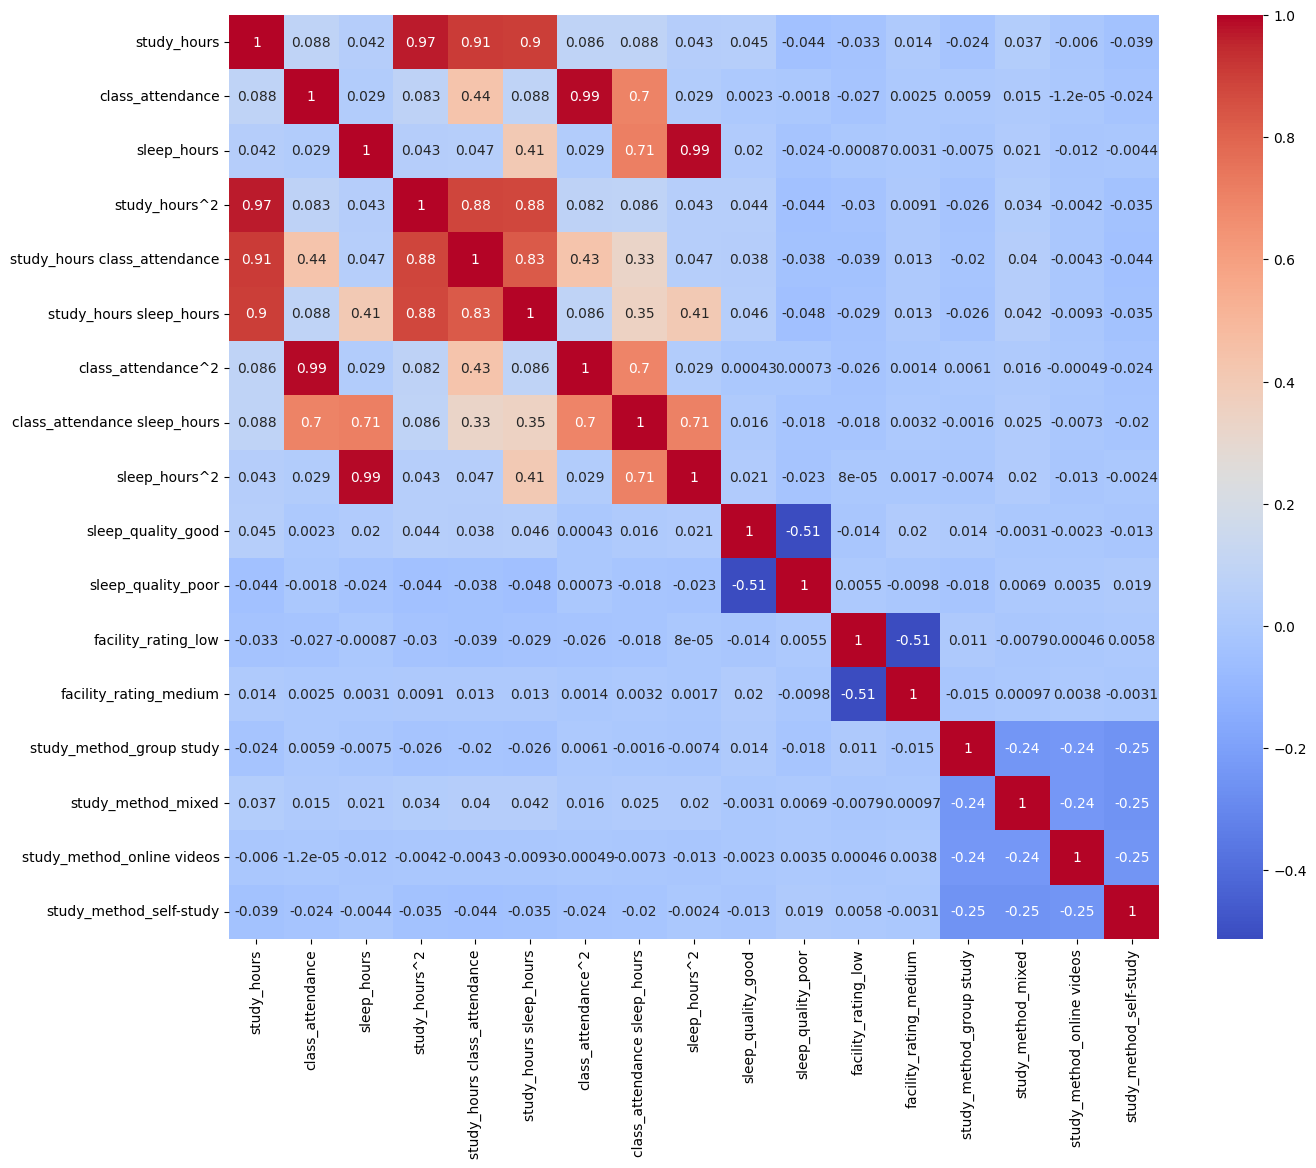

In [45]:
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(X_final_poly.corr(), annot=True, cmap="coolwarm", ax=ax)

# Prediction

### Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(numeric_cat_data, train_data["exam_score"])
y_pred_lr = lr.predict(numeric_cat_data)
root_mean_squared_error(train_data["exam_score"], np.clip(y_pred_lr, 0, 100))

8.891669603497343

In [59]:
cat_test_data = enc.transform(test_data[["sleep_quality", "facility_rating", "study_method"]])
cat_test_data = pd.DataFrame(cat_test_data, columns=enc.get_feature_names_out())
numeric_cat_test_data = pd.concat([test_data[["study_hours", "class_attendance", "sleep_hours"]], cat_test_data], axis=1)
test_pred = np.clip(lr.predict(numeric_cat_test_data), 0, 100)
submission = pd.DataFrame({
    "id": test_data["id"],
    "exam_score": test_pred
})
submission.to_csv("linear_regression_submission.csv", index=False)

### Huber Regressor

In [58]:
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

# Huber requires scaling (unlike OLS, it relies on distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_cat_data)

# Epsilon=1.35 is the standard "cutoff" for what counts as an outlier
huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_scaled, train_data["exam_score"])

y_pred_huber = np.clip(huber.predict(X_scaled), 0, 100)
print(f"Huber RMSE: {root_mean_squared_error(train_data['exam_score'], y_pred_huber)}")
print(f"Huber R^2: {r2_score(train_data['exam_score'], y_pred_huber)}")

Huber RMSE: 8.891919694321182
Huber R^2: 0.7790507433461171


In [60]:
test_pred_huber = np.clip(huber.predict(scaler.transform(numeric_cat_test_data)), 0, 100)
submission_huber = pd.DataFrame({
    "id": test_data["id"],
    "exam_score": test_pred_huber
})
submission_huber.to_csv("huber_regression_submission.csv", index=False)